# Support Vector Machine — An Illustrated Tour

> An SVM finds the **widest possible margin** between two classes. Points on the margin edge are the **support vectors** — everything else is irrelevant to the boundary.

---

**What we cover:**
- The maximum-margin hyperplane
- Support vectors — the critical points
- Soft margin — handling non-separable data (the C parameter)
- The kernel trick — non-linear decision boundaries
- Comparing kernels: linear, polynomial, RBF
- ROC curve and metrics

## The picture — maximum-margin hyperplane held up by support vectors

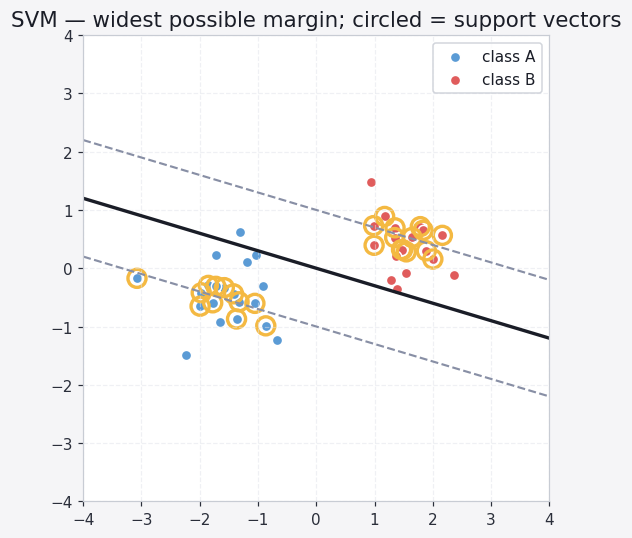

In [1]:
# (schematic — drawn from smooth curves, not measured)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow, FancyBboxPatch, Ellipse, Rectangle, Circle, FancyArrowPatch
plt.rcParams.update({
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'legend.facecolor':'#ffffff','legend.edgecolor':'#c8ccd4','figure.dpi':110,
})
P = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']
rng = np.random.RandomState(0)
A = rng.randn(20, 2)*0.5 + np.array([-1.8, -0.5])
B = rng.randn(20, 2)*0.5 + np.array([ 1.8,  0.5])
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(A[:,0], A[:,1], s=45, color=P[0], edgecolor='white', label='class A')
ax.scatter(B[:,0], B[:,1], s=45, color=P[1], edgecolor='white', label='class B')
xx = np.linspace(-4, 4, 50); m = -0.3
for off, c, lw, ls in [(0,'#1a1d27',2.2,'-'),(1,'#888fa5',1.4,'--'),(-1,'#888fa5',1.4,'--')]:
    ax.plot(xx, m*xx + off, color=c, lw=lw, ls=ls)
# Highlight support vectors near margins
def near_margin(P_, off): return P_[np.abs(P_[:,1]-(m*P_[:,0]+off)) < 0.35]
for cls, off in [(A, -1), (B, 1)]:
    sv = near_margin(cls, off)
    ax.scatter(sv[:,0], sv[:,1], s=140, facecolor='none', edgecolor=P[2], lw=2.2)
ax.set_xlim(-4,4); ax.set_ylim(-4,4); ax.set_aspect('equal')
ax.set_title('SVM — widest possible margin; circled = support vectors')
ax.legend(); ax.grid(True); plt.tight_layout(); plt.show()


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_classification, make_moons, make_circles
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, roc_curve, auc,
                              accuracy_score, precision_score, recall_score, f1_score)

PLT_STYLE = {
    'figure.facecolor':'#f5f5f7', 'axes.facecolor':'#ffffff',
    'axes.edgecolor':'#c8ccd4',   'axes.labelcolor':'#1a1d27',
    'axes.titlecolor':'#1a1d27',  'xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a',      'grid.color':'#e0e3ea',
    'grid.linestyle': '--',        'grid.alpha': 0.5,
    'text.color':'#1a1d27',       'font.family': 'DejaVu Sans',
    'axes.titlesize': 17,          'axes.labelsize': 13,
    'xtick.labelsize': 11,         'ytick.labelsize': 11,
    'legend.fontsize': 11,         'legend.facecolor':'#ffffff',
    'legend.edgecolor':'#c8ccd4', 'figure.dpi': 120,
}
plt.rcParams.update(PLT_STYLE)

C0='#5b9bd5'; C1='#e05c5c'; CB='#f4b942'; CM='#7ecba1'; CH='#56b6c2'; CP='#c678dd'

np.random.seed(0)
X2, y2 = make_classification(n_samples=120, n_features=2, n_redundant=0,
                              n_informative=2, random_state=4,
                              n_clusters_per_class=1, class_sep=1.5)
sc2 = StandardScaler(); X2s = sc2.fit_transform(X2)

Xm, ym = make_moons(n_samples=200, noise=0.20, random_state=0)
Xc, yc = make_circles(n_samples=200, noise=0.12, factor=0.45, random_state=0)

X, y = make_classification(n_samples=200, n_features=20, n_informative=10, random_state=42)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
sc = StandardScaler()
X_tr_s = sc.fit_transform(X_tr); X_te_s = sc.transform(X_te)

print('Datasets ready')

Datasets ready


---
## The Maximum-Margin Hyperplane

Many lines can separate two classes. SVM picks the one with the **largest margin** — the widest gap between the two classes.

The margin width is $\frac{2}{\|w\|}$. Maximising the margin is equivalent to minimising $\|w\|^2$.

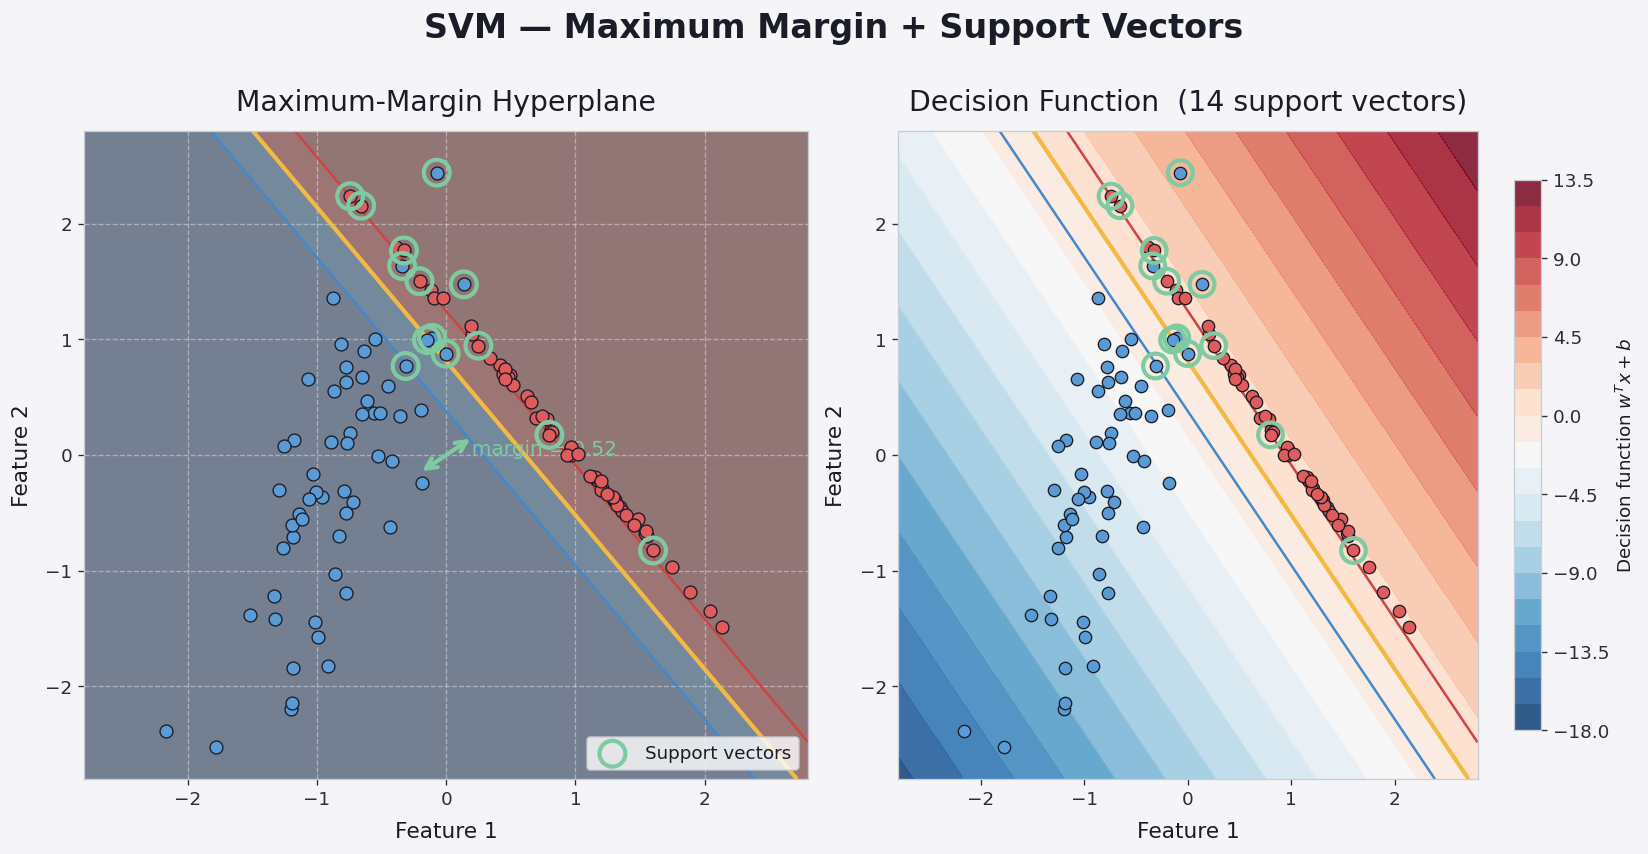

In [3]:
svm_lin = SVC(kernel='linear', C=1e6)   # hard margin (linearly separable data)
svm_lin.fit(X2s, y2)

w  = svm_lin.coef_[0]
b  = svm_lin.intercept_[0]
wn = w / np.linalg.norm(w)

xx, yy = np.meshgrid(np.linspace(-2.8, 2.8, 300), np.linspace(-2.8, 2.8, 300))
ZZ = svm_lin.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Left: margin illustration
ax = axes[0]
ax.contourf(xx, yy, ZZ, levels=[-999, -1, 0, 1, 999],
            colors=['#1a2a4a', '#1a3a5c', '#5c1a1a', '#4a1a1a'], alpha=0.6)
ax.contour(xx, yy, ZZ, levels=[-1, 0, 1],
           colors=['#4488cc', CB, '#cc4444'], linewidths=[1.5, 2.5, 1.5])

sv = svm_lin.support_vectors_
ax.scatter(X2s[y2==0,0], X2s[y2==0,1], c=C0, s=60, edgecolors='#1a1d27', lw=0.8, zorder=4)
ax.scatter(X2s[y2==1,0], X2s[y2==1,1], c=C1, s=60, edgecolors='#1a1d27', lw=0.8, zorder=4)
ax.scatter(sv[:,0], sv[:,1], s=240, facecolors='none', edgecolors=CM,
           linewidths=2.5, zorder=5, label='Support vectors')

# Draw margin width arrow
cx, cy = 0.0, 0.0
pt_p = np.array([cx, cy]) + wn / np.linalg.norm(w)
pt_n = np.array([cx, cy]) - wn / np.linalg.norm(w)
ax.annotate('', xy=pt_p[:2], xytext=pt_n[:2],
            arrowprops=dict(arrowstyle='<->', color=CM, lw=2.5, mutation_scale=16))
margin_w = 2 / np.linalg.norm(w)
ax.text(cx+0.1, cy, f'  margin = {margin_w:.2f}', fontsize=12, color=CM)

ax.set_xlim(-2.8, 2.8); ax.set_ylim(-2.8, 2.8)
ax.set_xlabel('Feature 1', labelpad=8); ax.set_ylabel('Feature 2', labelpad=8)
ax.set_title('Maximum-Margin Hyperplane', pad=12)
ax.legend(loc='lower right'); ax.grid(True)

# Right: decision function (distance to boundary)
ax = axes[1]
im = ax.contourf(xx, yy, ZZ, levels=20, cmap='RdBu_r', alpha=0.85)
ax.contour(xx, yy, ZZ, levels=[-1,0,1],
           colors=['#4488cc', CB, '#cc4444'], linewidths=[1.5,2.5,1.5])
ax.scatter(X2s[y2==0,0], X2s[y2==0,1], c=C0, s=55, edgecolors='#1a1d27', lw=0.8, zorder=4)
ax.scatter(X2s[y2==1,0], X2s[y2==1,1], c=C1, s=55, edgecolors='#1a1d27', lw=0.8, zorder=4)
ax.scatter(sv[:,0], sv[:,1], s=220, facecolors='none', edgecolors=CM, lw=2.5, zorder=5)
cbar = plt.colorbar(im, ax=ax, shrink=0.85)
cbar.set_label('Decision function $w^Tx + b$', fontsize=11)
cbar.ax.tick_params(labelcolor='#2a2e3a')
ax.set_xlim(-2.8, 2.8); ax.set_ylim(-2.8, 2.8)
ax.set_xlabel('Feature 1', labelpad=8); ax.set_ylabel('Feature 2', labelpad=8)
ax.set_title(f'Decision Function  ({len(sv)} support vectors)', pad=12)
ax.grid(False)

fig.suptitle('SVM — Maximum Margin + Support Vectors', fontsize=20, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

---
## Soft Margin — The C Parameter

Real data is rarely perfectly separable. The **soft margin** SVM allows misclassifications,
controlled by parameter $C$:

- Small $C$: allow more misclassifications → **wider margin**, simpler boundary
- Large $C$: allow few misclassifications → **narrower margin**, more complex boundary

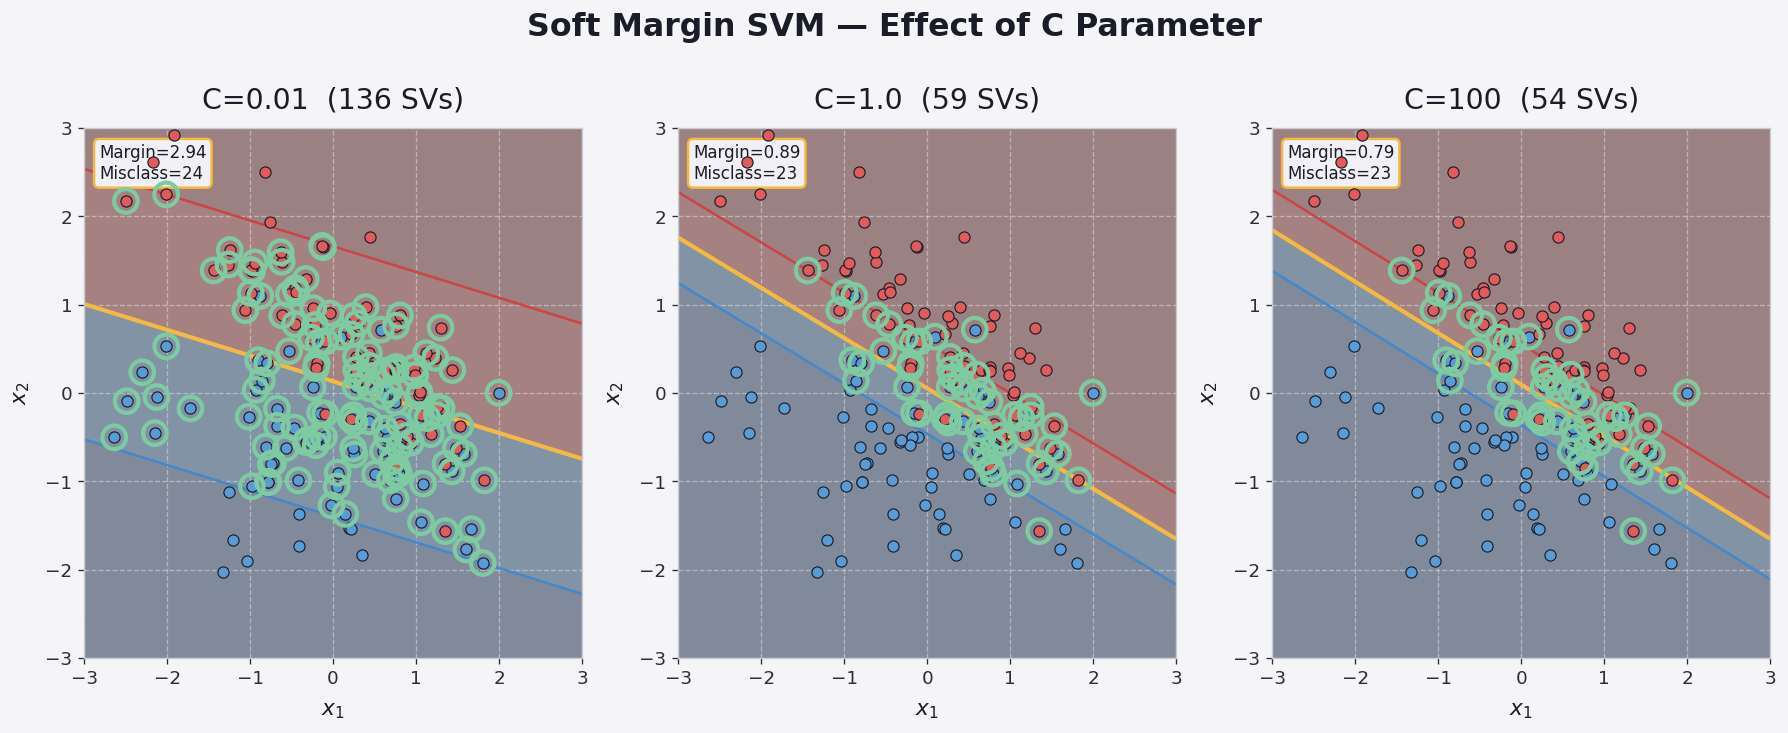

In [4]:
Xn, yn = make_classification(n_samples=150, n_features=2, n_redundant=0,
                              n_informative=2, random_state=0,
                              n_clusters_per_class=1, class_sep=0.8)
scn  = StandardScaler(); Xns = scn.fit_transform(Xn)
xxn, yyn = np.meshgrid(np.linspace(-3,3,300), np.linspace(-3,3,300))

C_vals = [0.01, 1.0, 100]
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

for ax, C_v in zip(axes, C_vals):
    svm_c = SVC(kernel='linear', C=C_v)
    svm_c.fit(Xns, yn)
    ZZ_c  = svm_c.decision_function(np.c_[xxn.ravel(), yyn.ravel()]).reshape(xxn.shape)
    sv_c  = svm_c.support_vectors_
    margin_c = 2 / np.linalg.norm(svm_c.coef_[0])

    ax.contourf(xxn, yyn, ZZ_c, levels=[-999,-1,0,1,999],
                colors=['#1a2a4a','#1a3a5c','#5c1a1a','#4a1a1a'], alpha=0.55)
    ax.contour(xxn, yyn, ZZ_c, levels=[-1,0,1],
               colors=['#4488cc', CB, '#cc4444'], linewidths=[1.5,2.5,1.5])
    ax.scatter(Xns[yn==0,0], Xns[yn==0,1], c=C0, s=45, edgecolors='#1a1d27', lw=0.7, zorder=4)
    ax.scatter(Xns[yn==1,0], Xns[yn==1,1], c=C1, s=45, edgecolors='#1a1d27', lw=0.7, zorder=4)
    ax.scatter(sv_c[:,0], sv_c[:,1], s=200, facecolors='none',
               edgecolors=CM, linewidths=2.5, zorder=5)
    misclass = np.sum(svm_c.predict(Xns) != yn)
    ax.set_xlabel('$x_1$', labelpad=8); ax.set_ylabel('$x_2$', labelpad=8)
    ax.set_title(f'C={C_v}  ({len(sv_c)} SVs)', pad=12); ax.grid(True)
    ax.text(0.03, 0.97,
            f'Margin={margin_c:.2f}\nMisclass={misclass}',
            transform=ax.transAxes, fontsize=10, va='top',
            bbox=dict(boxstyle='round', fc='#f0f0f5', ec=CB, lw=1.5))

fig.suptitle('Soft Margin SVM — Effect of C Parameter', fontsize=19, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

---
## The Kernel Trick — Non-Linear Boundaries

For non-linearly separable data, we **implicitly** map inputs to a higher-dimensional space using a kernel function $K(x, z) = \langle \phi(x), \phi(z) \rangle$.
The decision function is computed entirely in terms of kernel evaluations — $\phi$ is never explicitly computed.

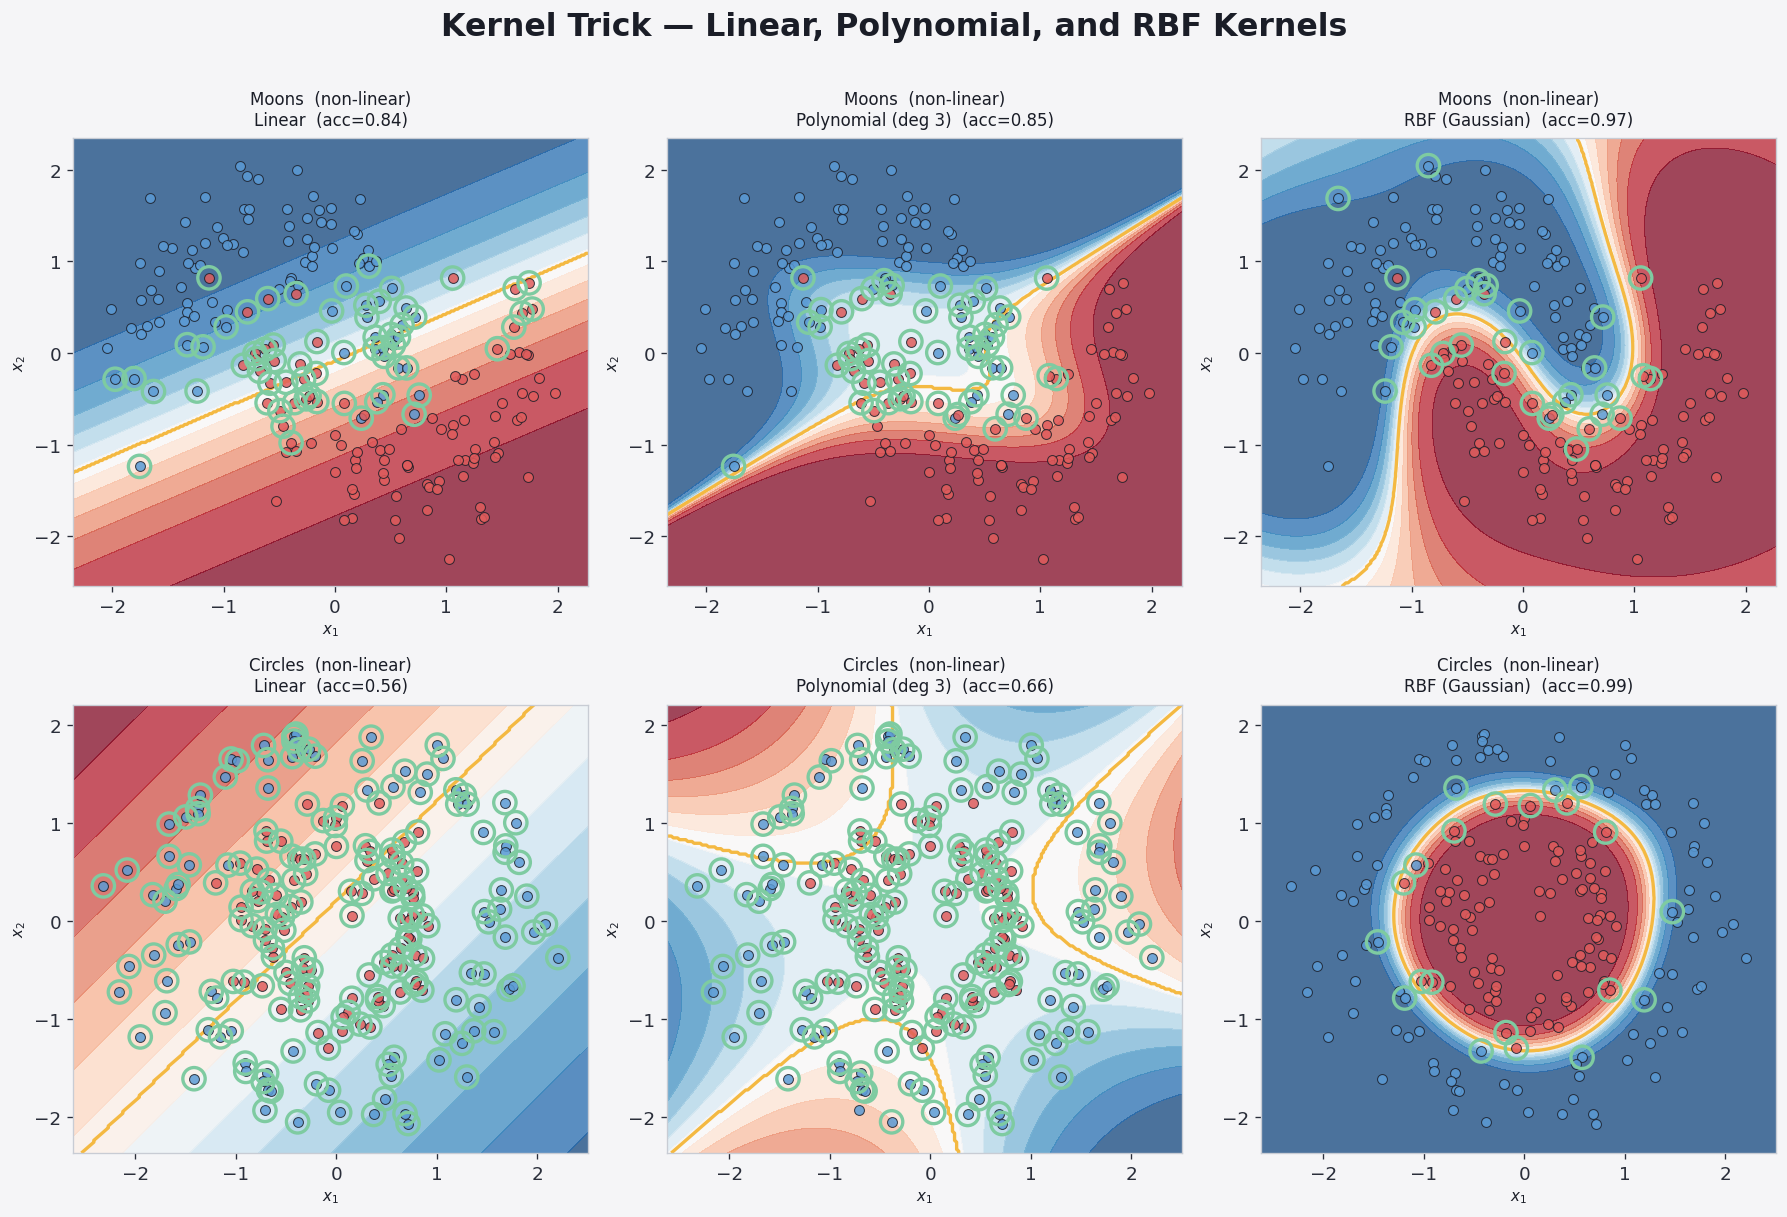

In [5]:
datasets = [
    (Xm, ym, 'Moons  (non-linear)'),
    (Xc, yc, 'Circles  (non-linear)'),
]
kernels  = ['linear', 'poly', 'rbf']
klabels  = ['Linear', 'Polynomial (deg 3)', 'RBF (Gaussian)']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for row, (Xd, yd, dname) in enumerate(datasets):
    sc_d  = StandardScaler(); Xds = sc_d.fit_transform(Xd)
    xxd, yyd = np.meshgrid(np.linspace(Xds[:,0].min()-0.3, Xds[:,0].max()+0.3, 250),
                           np.linspace(Xds[:,1].min()-0.3, Xds[:,1].max()+0.3, 250))
    for col, (kern, klbl) in enumerate(zip(kernels, klabels)):
        ax = axes[row, col]
        svm_k = SVC(kernel=kern, C=10, degree=3, gamma='scale', probability=True)
        svm_k.fit(Xds, yd)
        ZZd = svm_k.predict_proba(np.c_[xxd.ravel(), yyd.ravel()])[:,1].reshape(xxd.shape)
        ax.contourf(xxd, yyd, ZZd, levels=15, cmap='RdBu_r', alpha=0.75)
        ax.contour(xxd, yyd, ZZd, levels=[0.5], colors=CB, linewidths=2)
        ax.scatter(Xds[yd==0,0], Xds[yd==0,1], c=C0, s=35, edgecolors='#1a1d27', lw=0.6, alpha=0.85, zorder=4)
        ax.scatter(Xds[yd==1,0], Xds[yd==1,1], c=C1, s=35, edgecolors='#1a1d27', lw=0.6, alpha=0.85, zorder=4)
        sv_k = svm_k.support_vectors_
        ax.scatter(sv_k[:,0], sv_k[:,1], s=180, facecolors='none', edgecolors=CM, lw=2, zorder=5)
        acc = accuracy_score(yd, svm_k.predict(Xds))
        ax.set_title(f'{dname}\n{klbl}  (acc={acc:.2f})', fontsize=10, pad=8)
        ax.set_xlabel('$x_1$', fontsize=9); ax.set_ylabel('$x_2$', fontsize=9)
        ax.grid(False)

fig.suptitle('Kernel Trick — Linear, Polynomial, and RBF Kernels',
             fontsize=19, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

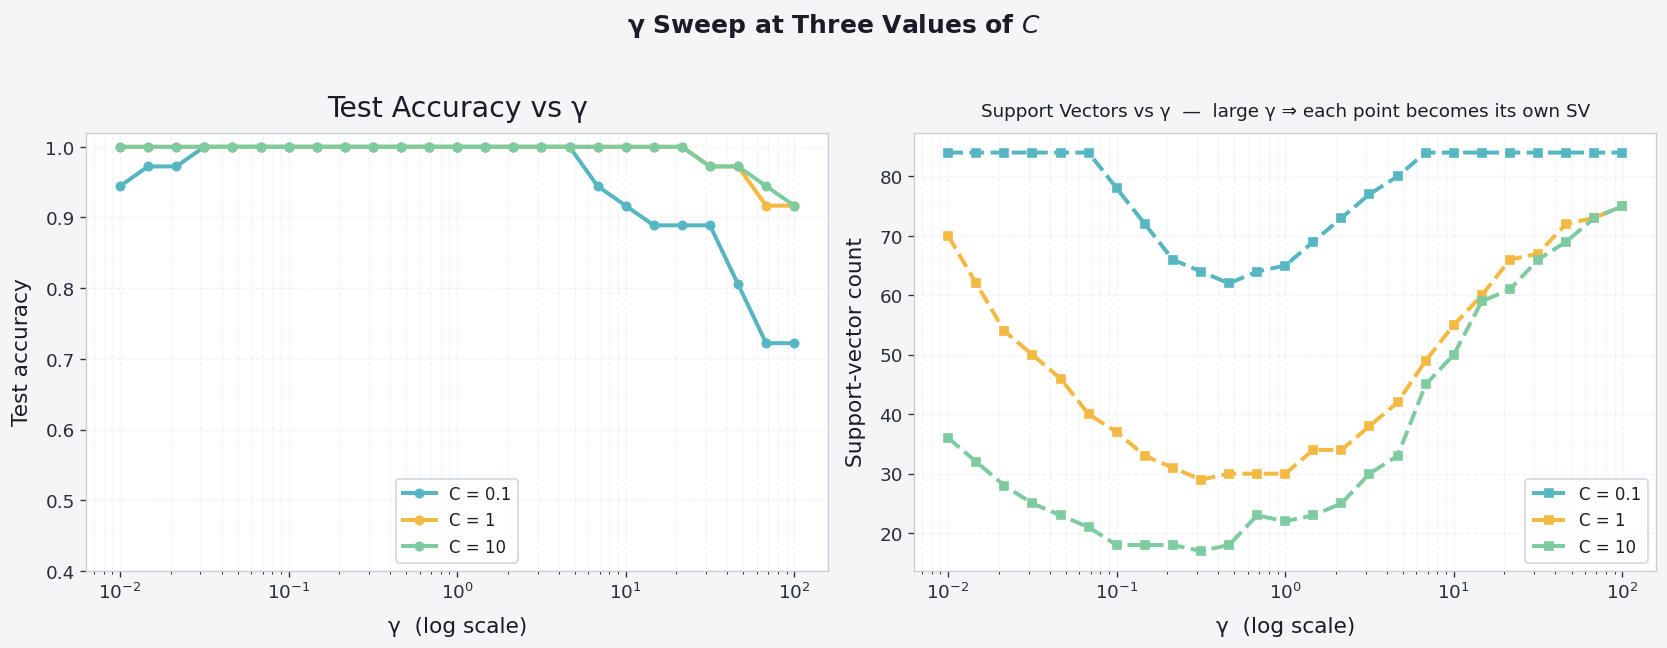

In [6]:
from sklearn.model_selection import train_test_split as _tts_sv
_Xtr_sv, _Xte_sv, _ytr_sv, _yte_sv = _tts_sv(X2s, y2, test_size=0.30, random_state=0, stratify=y2)

# γ sweep at three C values — test accuracy & support-vector count
_gammas = np.logspace(-2, 2, 25)
_sv_sweep, _te_sweep = {}, {}
for _Cf in [0.1, 1.0, 10.0]:
    _svs, _tes = [], []
    for _g in _gammas:
        _m = SVC(kernel='rbf', C=_Cf, gamma=_g).fit(_Xtr_sv, _ytr_sv)
        _svs.append(len(_m.support_vectors_))
        _tes.append(accuracy_score(_yte_sv, _m.predict(_Xte_sv)))
    _sv_sweep[_Cf] = _svs
    _te_sweep[_Cf] = _tes

_colors_C = {0.1: CH, 1.0: CB, 10.0: CM}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

ax = axes[0]
for _Cf, _curve in _te_sweep.items():
    ax.semilogx(_gammas, _curve, color=_colors_C[_Cf], lw=2.4,
                marker='o', ms=5, label=f'C = {_Cf:g}')
ax.set_xlabel('γ  (log scale)', labelpad=8)
ax.set_ylabel('Test accuracy', labelpad=8)
ax.set_title('Test Accuracy vs γ', pad=10)
ax.legend(loc='lower center', fontsize=10); ax.grid(True, which='both', alpha=0.4)
ax.set_ylim(0.4, 1.02)

ax = axes[1]
for _Cf, _curve in _sv_sweep.items():
    ax.semilogx(_gammas, _curve, color=_colors_C[_Cf], lw=2.4,
                marker='s', ms=5, ls='--', label=f'C = {_Cf:g}')
ax.set_xlabel('γ  (log scale)', labelpad=8)
ax.set_ylabel('Support-vector count', labelpad=8)
ax.set_title('Support Vectors vs γ  —  large γ ⇒ each point becomes its own SV',
             pad=10, fontsize=11)
ax.legend(loc='lower right', fontsize=10); ax.grid(True, which='both', alpha=0.4)

fig.suptitle('γ Sweep at Three Values of $C$',
             fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout(); plt.show()


---
## Metrics — Confusion Matrix & ROC

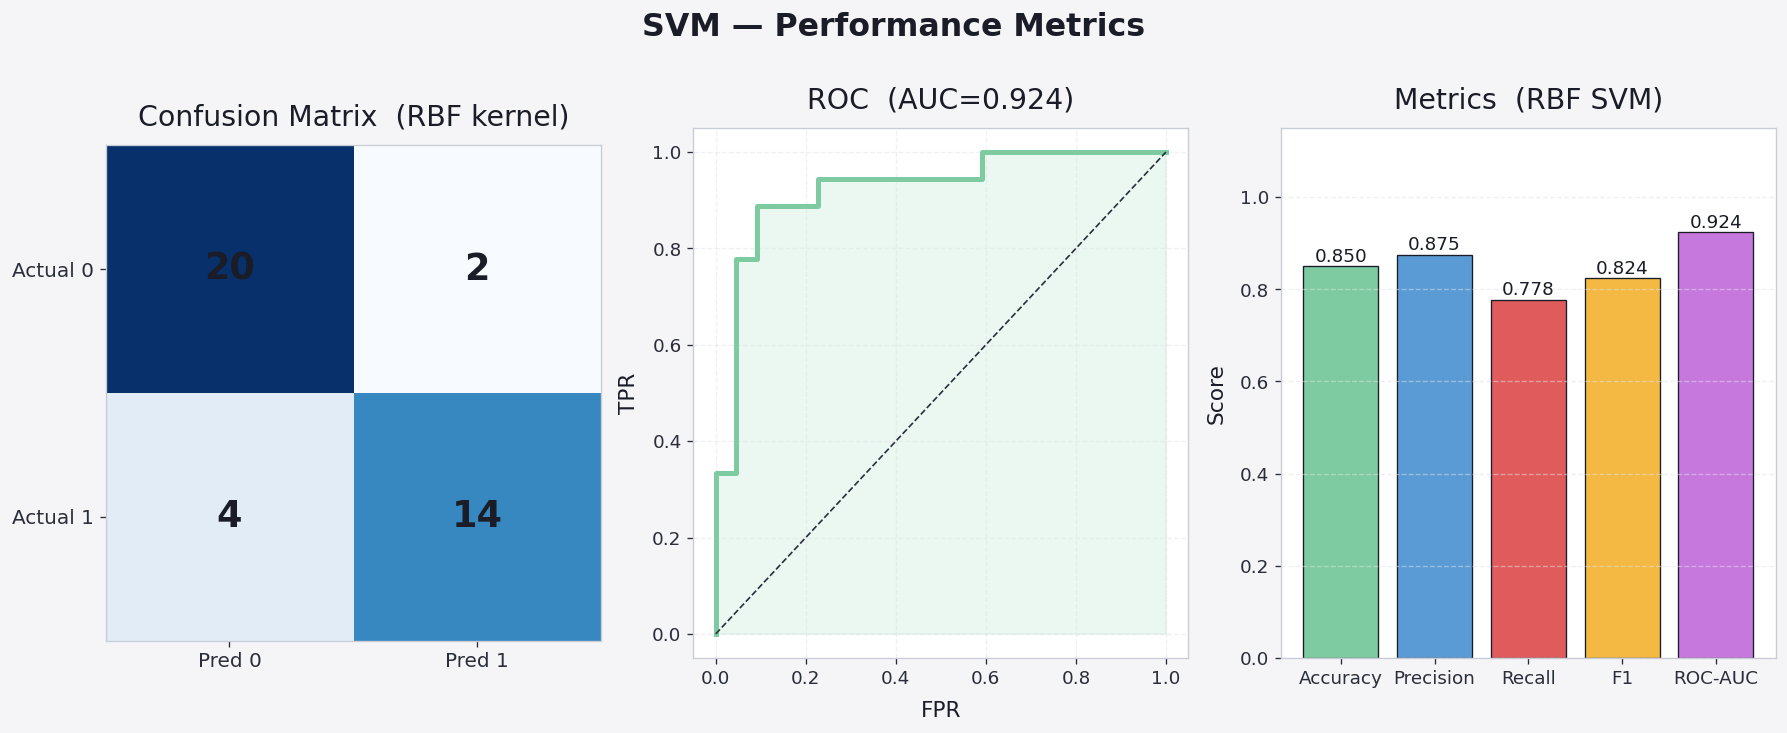

In [7]:
svm_final = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True)
svm_final.fit(X_tr_s, y_tr)
preds   = svm_final.predict(X_te_s)
probs   = svm_final.predict_proba(X_te_s)[:,1]
cm      = confusion_matrix(y_te, preds)
fpr, tpr, _ = roc_curve(y_te, probs)
roc_auc = auc(fpr, tpr)

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

ax = axes[0]
ax.imshow(cm, cmap='Blues')
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i,j]), ha='center', va='center', fontsize=22, fontweight='bold',
                color='#1a1d27' if cm[i,j]>cm.max()/2 else '#1a1d27')
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(['Pred 0','Pred 1'], fontsize=12)
ax.set_yticklabels(['Actual 0','Actual 1'], fontsize=12)
ax.set_title('Confusion Matrix  (RBF kernel)', pad=12)

ax = axes[1]
ax.plot(fpr, tpr, color=CM, lw=3)
ax.fill_between(fpr, tpr, alpha=0.15, color=CM)
ax.plot([0,1],[0,1], color='#2a2e3a', ls='--', lw=1)
ax.set_xlabel('FPR', labelpad=8); ax.set_ylabel('TPR', labelpad=8)
ax.set_title(f'ROC  (AUC={roc_auc:.3f})', pad=12)
ax.grid(True)

ax = axes[2]
metrics_vals = {
    'Accuracy':  accuracy_score(y_te, preds),
    'Precision': precision_score(y_te, preds),
    'Recall':    recall_score(y_te, preds),
    'F1':        f1_score(y_te, preds),
    'ROC-AUC':   roc_auc,
}
bars = ax.bar(list(metrics_vals.keys()), list(metrics_vals.values()),
              color=[CM, C0, C1, CB, CP], edgecolor='#1a1d27', lw=0.8)
for bar, val in zip(bars, metrics_vals.values()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{val:.3f}', ha='center', fontsize=11)
ax.set_ylim(0, 1.15); ax.set_ylabel('Score', labelpad=8)
ax.set_title('Metrics  (RBF SVM)', pad=12)
ax.grid(True, axis='y')

fig.suptitle('SVM — Performance Metrics', fontsize=19, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

---
## Everything on One Canvas

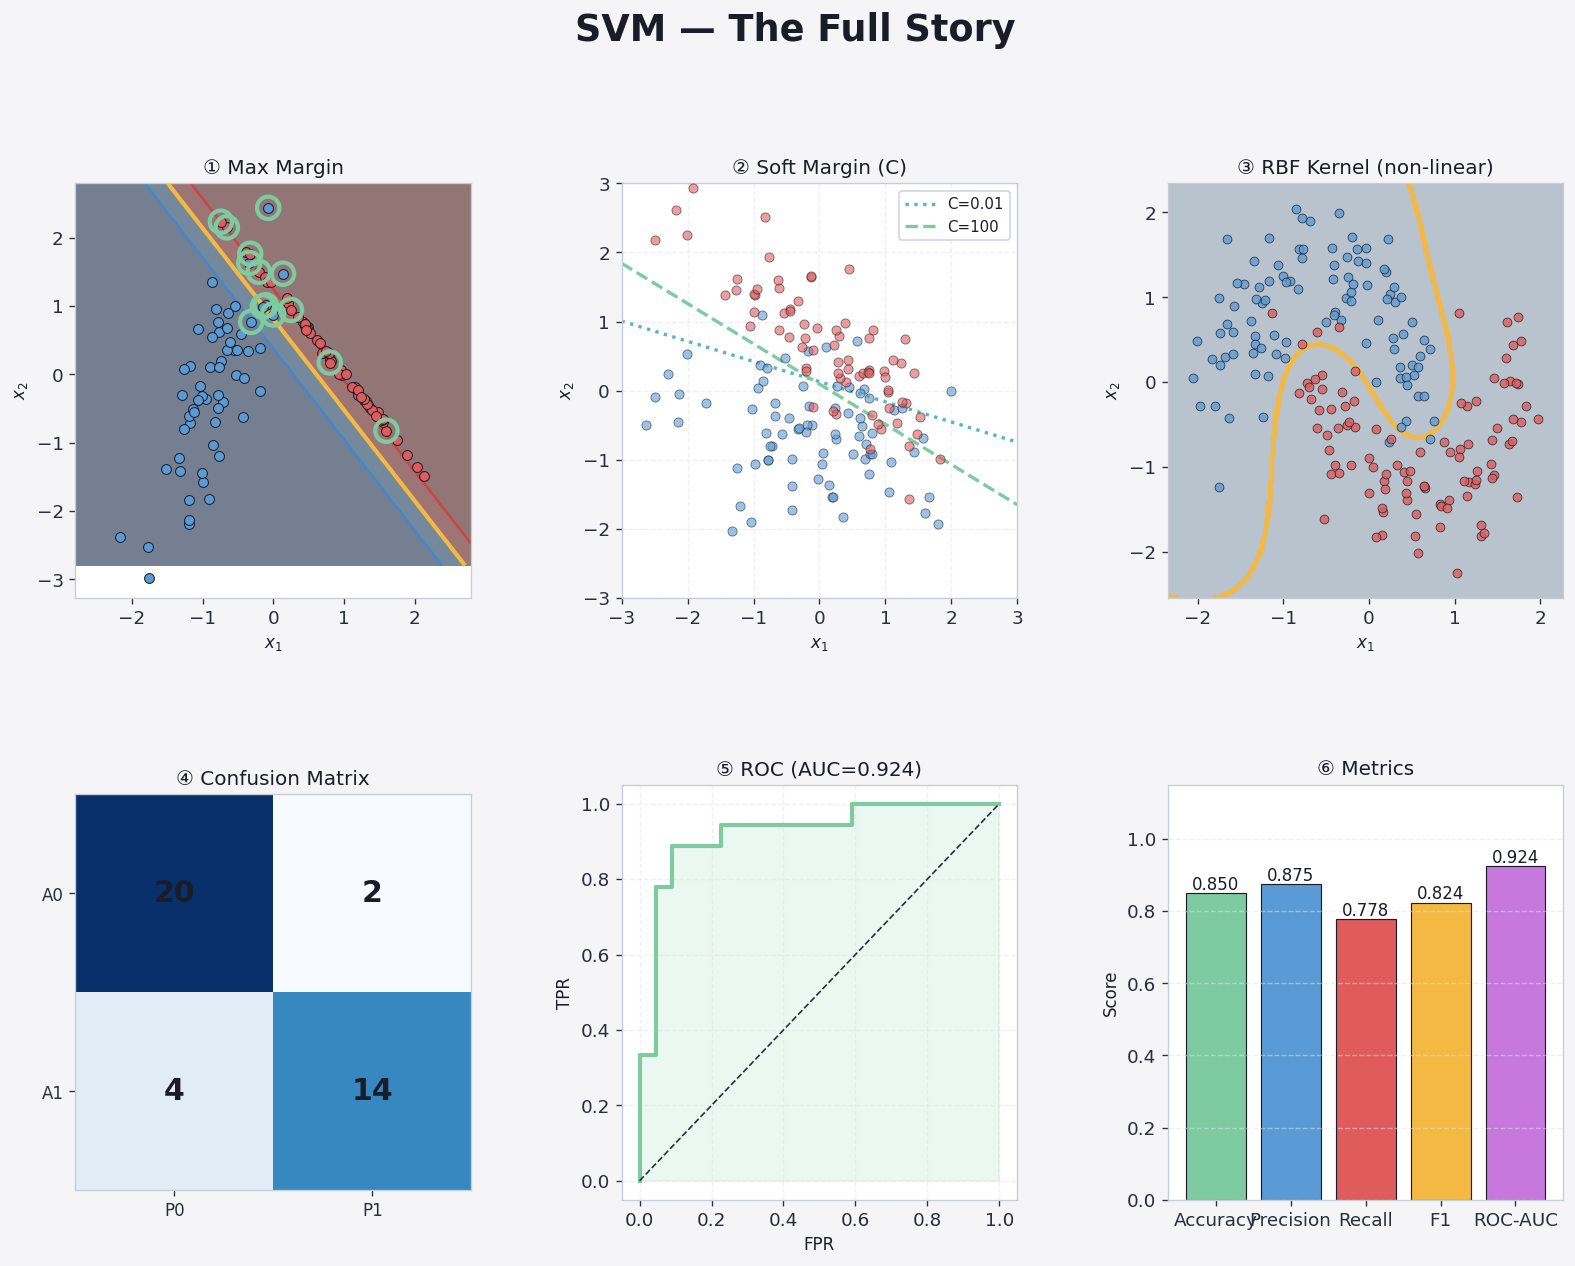

In [8]:
fig = plt.figure(figsize=(16, 11), facecolor='#f5f5f7')
gs  = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

ax = fig.add_subplot(gs[0,0])
ax.contourf(xx,yy,ZZ,levels=[-999,-1,0,1,999],colors=['#1a2a4a','#1a3a5c','#5c1a1a','#4a1a1a'],alpha=0.6)
ax.contour(xx,yy,ZZ,levels=[-1,0,1],colors=['#4488cc',CB,'#cc4444'],linewidths=[1.5,2.5,1.5])
ax.scatter(X2s[y2==0,0],X2s[y2==0,1],c=C0,s=35,edgecolors='#1a1d27',lw=0.6,zorder=4)
ax.scatter(X2s[y2==1,0],X2s[y2==1,1],c=C1,s=35,edgecolors='#1a1d27',lw=0.6,zorder=4)
ax.scatter(sv[:,0],sv[:,1],s=180,facecolors='none',edgecolors=CM,lw=2.5,zorder=5)
ax.set_title('① Max Margin',fontsize=12);ax.set_xlabel('$x_1$',fontsize=10);ax.set_ylabel('$x_2$',fontsize=10)

ax = fig.add_subplot(gs[0,1])
svm_c1 = SVC(kernel='linear',C=0.01);svm_c1.fit(Xns,yn)
svm_c2 = SVC(kernel='linear',C=100); svm_c2.fit(Xns,yn)
ZZ_c1=svm_c1.decision_function(np.c_[xxn.ravel(),yyn.ravel()]).reshape(xxn.shape)
ZZ_c2=svm_c2.decision_function(np.c_[xxn.ravel(),yyn.ravel()]).reshape(xxn.shape)
ax.scatter(Xns[yn==0,0],Xns[yn==0,1],c=C0,s=30,edgecolors='#1a1d27',lw=0.5,alpha=0.6,zorder=3)
ax.scatter(Xns[yn==1,0],Xns[yn==1,1],c=C1,s=30,edgecolors='#1a1d27',lw=0.5,alpha=0.6,zorder=3)
ax.contour(xxn,yyn,ZZ_c1,levels=[0],colors=[CH],linewidths=2,linestyles=[':'])
ax.contour(xxn,yyn,ZZ_c2,levels=[0],colors=[CM],linewidths=2,linestyles=['--'])
ax.legend(handles=[Line2D([0],[0],color=CH,lw=2,ls=':',label='C=0.01'),
                   Line2D([0],[0],color=CM,lw=2,ls='--',label='C=100')],fontsize=9)
ax.set_title('② Soft Margin (C)',fontsize=12);ax.set_xlabel('$x_1$',fontsize=10);ax.set_ylabel('$x_2$',fontsize=10);ax.grid(True)

# Moons RBF
scm=StandardScaler();Xms=scm.fit_transform(Xm)
xxm,yym=np.meshgrid(np.linspace(Xms[:,0].min()-0.3,Xms[:,0].max()+0.3,250),
                    np.linspace(Xms[:,1].min()-0.3,Xms[:,1].max()+0.3,250))
svmr=SVC(kernel='rbf',C=10,gamma='scale');svmr.fit(Xms,ym)
ZZm=svmr.predict(np.c_[xxm.ravel(),yym.ravel()]).reshape(xxm.shape)
ax=fig.add_subplot(gs[0,2])
ax.contourf(xxm,yym,ZZm,alpha=0.3,colors=['#1a3a5c','#5c1a1a'])
ax.contour(xxm,yym,ZZm,colors=CB,linewidths=2)
ax.scatter(Xms[ym==0,0],Xms[ym==0,1],c=C0,s=28,edgecolors='#1a1d27',lw=0.5,alpha=0.8,zorder=4)
ax.scatter(Xms[ym==1,0],Xms[ym==1,1],c=C1,s=28,edgecolors='#1a1d27',lw=0.5,alpha=0.8,zorder=4)
ax.set_title('③ RBF Kernel (non-linear)',fontsize=12);ax.set_xlabel('$x_1$',fontsize=10);ax.set_ylabel('$x_2$',fontsize=10)

ax=fig.add_subplot(gs[1,0])
ax.imshow(cm,cmap='Blues')
for i in range(2):
    for j in range(2):
        ax.text(j,i,str(cm[i,j]),ha='center',va='center',fontsize=18,fontweight='bold',
                color='#1a1d27' if cm[i,j]>cm.max()/2 else '#1a1d27')
ax.set_xticks([0,1]);ax.set_yticks([0,1])
ax.set_xticklabels(['P0','P1'],fontsize=10);ax.set_yticklabels(['A0','A1'],fontsize=10)
ax.set_title('④ Confusion Matrix',fontsize=12)

ax=fig.add_subplot(gs[1,1])
ax.plot(fpr,tpr,color=CM,lw=2.5);ax.fill_between(fpr,tpr,alpha=0.15,color=CM)
ax.plot([0,1],[0,1],color='#2a2e3a',ls='--',lw=1)
ax.set_title(f'⑤ ROC (AUC={roc_auc:.3f})',fontsize=12)
ax.set_xlabel('FPR',fontsize=10);ax.set_ylabel('TPR',fontsize=10);ax.grid(True)

ax=fig.add_subplot(gs[1,2])
bars=ax.bar(list(metrics_vals.keys()),list(metrics_vals.values()),color=[CM,C0,C1,CB,CP],edgecolor='#1a1d27',lw=0.7)
for bar,val in zip(bars,metrics_vals.values()):
    ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.01,f'{val:.3f}',ha='center',fontsize=10)
ax.set_ylim(0,1.15);ax.set_ylabel('Score',fontsize=10);ax.set_title('⑥ Metrics',fontsize=12);ax.grid(True,axis='y')

fig.suptitle('SVM — The Full Story',fontsize=22,fontweight='bold',color='#1a1d27',y=1.01)
plt.show()

---
## ⚖️ When to use SVM — and when not to

| Situation | Linear SVM | RBF SVM | Logistic | Random Forest |
|---|---|---|---|---|
| Wide margin, clean data | ✅ | ✅ | partial | ✅ |
| Non-linear, mid-size data | ❌ | ✅ kernel trick | ❌ | ✅ |
| Big data ($n > 10^5$) | ✅ liblinear | ❌ $O(n^2)$ | ✅ | ✅ |
| Need probability outputs | partial (Platt) | partial | ✅ native | partial |

> Reach for SVM when **margin** is the right notion (small / medium clean data) and you don't need probabilities.


---
## 🎯 Try this

1. **C × γ grid.** Fit a fine grid over $(\log C, \log \gamma)$ and plot validation accuracy as a heatmap — you'll see a single sweet-spot ridge.
2. **Kernel comparison.** RBF, polynomial degree 3, and a custom string / Tanimoto kernel on the same data. Visualise their boundaries.
3. **Support vectors only.** Refit using *only* the support vectors from the first fit. The boundary should be identical — this is the geometric core of the model.


---
## Summary

| Concept | Formula / Description | Key Insight |
|---|---|---|
| Margin | $\frac{2}{\lVert w \rVert}$ | SVM maximises this |
| Support vectors | Points on or inside the margin | Only these define the boundary |
| Hard margin | No misclassifications allowed | Requires linearly separable data |
| Soft margin | Allow misclassifications at cost $C$ | $C$ small = wide margin; $C$ large = narrow margin |
| Linear kernel | $K(x,z) = x^Tz$ | Linear boundary — fastest |
| RBF kernel | $K(x,z) = \exp(-\gamma\lVert x-z \rVert^2)$ | Most common; works for non-linear data |
| Polynomial kernel | $K(x,z) = (x^Tz + c)^d$ | Captures feature interactions up to degree $d$ |
| `gamma` (RBF) | Bandwidth of the Gaussian | Small = smooth boundary; large = complex/overfit |

**Key insight:** SVM's power comes from two ideas: (1) the maximum-margin principle prevents overfitting by choosing the most confident separator; (2) the kernel trick enables non-linear boundaries without ever explicitly computing the feature mapping.